# Section-Aware vs. Unlabeled Retrieval for Clinical RAG
### Research Question
**Does retrieving section-labeled evidence (background / methods / results / conclusions) improve the relevance and factual grounding of answers to clinical questions, compared to retrieving unlabeled sentence chunks?**

**Dataset:** PubMed 20k RCT (`train.txt`, `dev.txt`, `test.txt`) — abstracts of randomized controlled trials, with every sentence tagged by its role (BACKGROUND, OBJECTIVE, METHODS, RESULTS, CONCLUSIONS).

**Design philosophy of this notebook:**
- Written in an **Object-Oriented (OOP)** style — every stage of the pipeline (loading, classifying, retrieving, evaluating) is its own class with a single responsibility. This makes the two retrieval strategies directly swappable and comparable under identical conditions, which is essential for a fair experiment.
- Uses only **CPU-friendly, dependency-light** tools (TF-IDF + Logistic Regression + cosine similarity) rather than deep transformer models. This is a deliberate choice, justified in Section 2, so the notebook runs end-to-end on a laptop with no GPU and no internet dependency (no large model downloads).
- Every method includes an inline justification comment explaining *why* that technique was chosen over alternatives.


## Section 1 — Imports and Configuration

We import only well-established, CPU-light libraries:
- `pandas` / `numpy` — data handling.
- `scikit-learn` — TF-IDF vectorization, Logistic Regression classifier, cosine similarity. Chosen because it is fast, interpretable, requires no GPU, and (unlike sentence-transformer models) needs no internet download — important for reproducibility on any machine.
- `matplotlib` — plotting the comparison results.
- `dataclasses` / `typing` / `abc` — used to write clean, self-documenting OOP code (data containers, type hints, and abstract base classes to enforce a consistent retriever interface).


In [1]:
import re
import random
from dataclasses import dataclass, field
from typing import List, Tuple, Dict
from abc import ABC, abstractmethod

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity

# Reproducibility: fix the random seed so sampling of evaluation queries
# is identical every time this notebook is re-run.
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# File paths — update these if your files live elsewhere.
TRAIN_PATH = "/mnt/user-data/uploads/train.txt"
DEV_PATH   = "/mnt/user-data/uploads/dev.txt"
TEST_PATH  = "/mnt/user-data/uploads/test.txt"


## Section 2 — Data Loading

**Why a dedicated loader class?**
The PubMed 20k RCT format is unusual: abstracts are separated by a `###PMID` header line, and every following line is `LABEL\tSENTENCE` until the next header. Wrapping this parsing logic in a `PubMedRCTLoader` class (rather than a loose script) means:
1. The parsing logic is written once and reused identically for `train.txt`, `dev.txt`, and `test.txt` — eliminating the risk of subtly different parsing per file (a common source of silent bugs).
2. It exposes a clean interface (`load()`, `to_dataframe()`) that later stages depend on, not on file-format details — if the raw format ever changes, only this class needs updating.

We also define a small `Abstract` dataclass. Using `@dataclass` instead of a plain dict makes the structure explicit and self-documenting (a PMID plus an ordered list of (label, sentence) tuples), which is preferable to passing around loosely-typed dictionaries.


In [2]:
@dataclass
class Abstract:
    """Represents a single RCT abstract: a PubMed ID plus its ordered,
    section-labeled sentences. Using a dataclass (rather than a dict)
    gives us type-checked, self-documenting fields."""
    pmid: str
    sentences: List[Tuple[str, str]] = field(default_factory=list)  # (label, sentence)


class PubMedRCTLoader:
    """
    Parses a PubMed-20k-RCT-formatted text file into a list of Abstract
    objects, and can flatten those into a sentence-level DataFrame.

    Justification for this design:
    - Single Responsibility Principle: this class does ONE thing (parsing),
      so retrieval/classification code never needs to know about the raw
      file format.
    - Streaming line-by-line (rather than loading the whole file into one
      big string and regex-splitting it) keeps memory use low and scales
      to the full 200k-abstract version of this dataset if needed later.
    """

    def __init__(self, path: str):
        self.path = path

    def load(self) -> List[Abstract]:
        abstracts: List[Abstract] = []
        current: Abstract = None

        with open(self.path, "r", encoding="utf-8") as f:
            for line in f:
                line = line.rstrip("\n")
                if not line.strip():
                    continue  # blank lines separate abstracts; skip them
                if line.startswith("###"):
                    # A new abstract begins here.
                    if current is not None:
                        abstracts.append(current)
                    current = Abstract(pmid=line[3:].strip())
                else:
                    if "\t" not in line:
                        continue  # malformed line safeguard
                    label, sentence = line.split("\t", 1)
                    if current is not None:
                        current.sentences.append((label.strip(), sentence.strip()))
        if current is not None:
            abstracts.append(current)
        return abstracts

    def to_dataframe(self, abstracts: List[Abstract]) -> pd.DataFrame:
        """Flattens abstracts into one row per sentence: (pmid, label, sentence).
        A flat table is the format every downstream sklearn tool expects."""
        rows = []
        for ab in abstracts:
            for label, sentence in ab.sentences:
                rows.append({"pmid": ab.pmid, "label": label, "sentence": sentence})
        return pd.DataFrame(rows)


In [3]:
# Load all three splits.
# Justification for keeping the train/dev/test split intact (rather than
# merging everything upfront): the SectionClassifier below must be trained
# ONLY on train.txt to avoid data leakage; dev.txt is reserved for tuning;
# test.txt is reserved for the final, untouched evaluation.

train_loader = PubMedRCTLoader(TRAIN_PATH)
dev_loader   = PubMedRCTLoader(DEV_PATH)
test_loader  = PubMedRCTLoader(TEST_PATH)

train_df = train_loader.to_dataframe(train_loader.load())
dev_df   = dev_loader.to_dataframe(dev_loader.load())
test_df  = test_loader.to_dataframe(test_loader.load())

print(f"train sentences: {len(train_df):,}")
print(f"dev sentences:   {len(dev_df):,}")
print(f"test sentences:  {len(test_df):,}")
train_df.head()


train sentences: 180,040
dev sentences:   30,212
test sentences:  30,135


,pmid,label,sentence
0,24293578,OBJECTIVE,To investigate the efficacy of 6 weeks of dail...
1,24293578,METHODS,A total of 125 patients with primary knee OA w...
2,24293578,METHODS,Outcome measures included pain reduction and i...
3,24293578,METHODS,Pain was assessed using the visual analog pain...
4,24293578,METHODS,Secondary outcome measures included the Wester...


In [4]:
# Quick sanity check: confirm the five expected section labels are present
# and see their distribution. This matters because a heavily imbalanced
# label distribution (e.g. very few BACKGROUND sentences) would make the
# section classifier in Section 3 less reliable for that class.
train_df['label'].value_counts()


label
METHODS        59353
RESULTS        57953
CONCLUSIONS    27168
BACKGROUND     21727
OBJECTIVE      13839
Name: count, dtype: int64

## Section 3 — Section Classifier

**Purpose:** The section-aware retriever needs to know, for any incoming *question*,
which section type (BACKGROUND/OBJECTIVE/METHODS/RESULTS/CONCLUSIONS) is most
likely to contain the answer. We train a classifier for this instead of
using hand-written keyword rules, because:
- A trained classifier generalizes better than a small hand-written keyword
  list (which would need constant manual expansion and is prone to bias
  from whichever keywords the author happened to think of).
- This dataset conveniently already provides ~180,000 labeled sentences, so
  supervised learning is the natural, low-cost choice — no extra
  annotation effort required.

**Why TF-IDF + Logistic Regression, not a deep model?**
- TF-IDF captures the vocabulary differences between section types well
  (e.g. METHODS sentences use "randomized", "administered"; RESULTS
  sentences use "significant", "increased", "p <"). This is a lexical
  classification task, not one requiring deep contextual understanding,
  so a bag-of-words-style model is an appropriate, well-justified choice.
- Logistic Regression trains in seconds on ~180k rows on CPU, is easy to
  inspect/debug, and is a standard, defensible baseline for text
  classification — an appropriate choice given the CPU constraint stated
  in the project brief.

**Leakage control:** the classifier is fit ONLY on `train_df`. We report
its accuracy on `dev_df` (never seen during training) as an honest
estimate of how well it will generalize — this mirrors standard ML
practice and avoids overstating performance.


In [5]:
class SectionClassifier:
    """
    Predicts which RCT section (BACKGROUND/OBJECTIVE/METHODS/RESULTS/
    CONCLUSIONS) a given piece of text most likely belongs to.

    Wrapped in its own class (rather than a bare function) so that the
    fitted vectorizer and model travel together as one unit, and so this
    component can later be swapped for a different model (e.g. an SVM or
    a small neural net) without touching any retrieval code.
    """

    def __init__(self, max_features: int = 20000, ngram_range: Tuple[int,int] = (1, 2)):
        # ngram_range=(1,2) captures short phrases like "p <" or "were randomized",
        # which carry more section-discriminating signal than single words alone.
        self.vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range)
        self.model = LogisticRegression(max_iter=300)
        self._fitted = False

    def fit(self, sentences: pd.Series, labels: pd.Series) -> "SectionClassifier":
        X = self.vectorizer.fit_transform(sentences)
        self.model.fit(X, labels)
        self._fitted = True
        return self

    def predict(self, texts: List[str]) -> np.ndarray:
        if not self._fitted:
            raise RuntimeError("Call .fit() before .predict().")
        X = self.vectorizer.transform(texts)
        return self.model.predict(X)

    def evaluate(self, sentences: pd.Series, labels: pd.Series) -> float:
        """Returns accuracy on a held-out set (use dev_df here, never test_df,
        to keep the final test evaluation completely unbiased)."""
        X = self.vectorizer.transform(sentences)
        return self.model.score(X, labels)


In [6]:
# Train ONLY on train_df (never on dev/test) to avoid leakage.
section_classifier = SectionClassifier()
section_classifier.fit(train_df['sentence'], train_df['label'])

# Validate on dev_df (held out from training) to get an honest accuracy estimate.
dev_accuracy = section_classifier.evaluate(dev_df['sentence'], dev_df['label'])
print(f"Section classifier accuracy on dev set: {dev_accuracy:.3f}")


Section classifier accuracy on dev set: 0.827


## Section 4 — Building the Retrieval Corpus and the Two Retrievers

**Corpus choice:** we index `train_df` + `dev_df` combined (~210k sentences)
as the searchable evidence base, and reserve `test_df` entirely for
generating evaluation queries later. This mirrors a realistic RAG setup:
the corpus is the "knowledge base," and test queries are unseen questions
a user might ask.

**Why TF-IDF + cosine similarity for retrieval (not embeddings)?**
- Consistent with the CPU-only constraint: no model downloads, indexing
  ~210k sentences with TF-IDF takes seconds, and cosine similarity search
  is a single sparse matrix multiplication — fast even on modest hardware.
- It is a transparent, standard information-retrieval baseline (functionally
  similar to classic BM25-style search), which makes it a fair and
  reproducible basis for comparing the two *retrieval strategies*
  (labeled vs. unlabeled) — the variable actually under study — without
  the comparison being confounded by embedding-model quality.
- The pipeline is written so the vectorizer could be swapped for a
  sentence-transformer embedding model later (see the `BaseRetriever`
  interface below) if GPU resources become available — the OOP design
  isolates that decision to one place.

**Why an abstract base class (`BaseRetriever`)?**
Defining a shared interface (`retrieve(query, k)`) that both retrievers
must implement guarantees they are used identically by the evaluator in
Section 5 — eliminating any chance that differences in how each retriever
is *called* (rather than how it *works*) explain the results.


In [7]:
# Build the shared retrieval corpus: train + dev sentences.
corpus_df = pd.concat([train_df, dev_df], ignore_index=True)

# One TF-IDF vectorizer for the corpus. max_features caps vocabulary size
# to keep memory/time bounded on CPU; ngram_range=(1,2) mirrors the
# classifier's choice for consistency and captures short clinical phrases.
corpus_vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))
corpus_matrix = corpus_vectorizer.fit_transform(corpus_df['sentence'])

print(f"Corpus size: {corpus_df.shape[0]:,} sentences")
print(f"Corpus TF-IDF matrix shape: {corpus_matrix.shape}")


Corpus size: 210,252 sentences
Corpus TF-IDF matrix shape: (210252, 30000)


In [8]:
class BaseRetriever(ABC):
    """
    Abstract base class defining the common retrieval interface.
    Both concrete retrievers below MUST implement `retrieve()` with this
    exact signature, so the evaluator can call either one interchangeably
    -- this is what makes the comparison between them fair and mechanical,
    not dependent on ad-hoc glue code.
    """

    @abstractmethod
    def retrieve(self, query: str, k: int = 5) -> pd.DataFrame:
        """Return the top-k most relevant rows from the corpus for `query`."""
        raise NotImplementedError


class FlatRetriever(BaseRetriever):
    """
    BASELINE ('unlabeled') strategy.

    Treats every sentence in the corpus identically, regardless of its
    section label, and simply returns the k sentences most similar to the
    query by cosine similarity. This represents the standard, naive RAG
    approach most tutorials implement -- our control condition.
    """

    def __init__(self, corpus_df: pd.DataFrame, vectorizer: TfidfVectorizer, corpus_matrix):
        self.corpus_df = corpus_df.reset_index(drop=True)
        self.vectorizer = vectorizer
        self.corpus_matrix = corpus_matrix

    def retrieve(self, query: str, k: int = 5) -> pd.DataFrame:
        query_vec = self.vectorizer.transform([query])
        sims = cosine_similarity(query_vec, self.corpus_matrix).flatten()
        top_idx = np.argsort(-sims)[:k]
        result = self.corpus_df.iloc[top_idx].copy()
        result['similarity'] = sims[top_idx]
        return result


class SectionAwareRetriever(BaseRetriever):
    """
    TREATMENT ('section-labeled') strategy.

    Step 1: classify the query into its most likely section type using the
             SectionClassifier trained in Section 3.
    Step 2: restrict the search space to ONLY corpus sentences carrying
             that same predicted label, then rank by cosine similarity
             within that restricted subset.

    Rationale: if a question is asking about *outcomes* ("did it work?"),
    restricting the search to RESULTS-labeled sentences should reduce
    interference from topically-similar-but-functionally-irrelevant
    sentences (e.g. a METHODS sentence that happens to share vocabulary
    with the query but doesn't answer it). This is precisely the mechanism
    the research question is testing.
    """

    def __init__(self, corpus_df: pd.DataFrame, vectorizer: TfidfVectorizer,
                 corpus_matrix, classifier: SectionClassifier):
        self.corpus_df = corpus_df.reset_index(drop=True)
        self.vectorizer = vectorizer
        self.corpus_matrix = corpus_matrix
        self.classifier = classifier

    def retrieve(self, query: str, k: int = 5) -> pd.DataFrame:
        predicted_label = self.classifier.predict([query])[0]

        mask = (self.corpus_df['label'] == predicted_label).values
        sub_df = self.corpus_df[mask]
        sub_matrix = self.corpus_matrix[mask]

        query_vec = self.vectorizer.transform([query])
        sims = cosine_similarity(query_vec, sub_matrix).flatten()
        top_idx = np.argsort(-sims)[:k]

        result = sub_df.iloc[top_idx].copy()
        result['similarity'] = sims[top_idx]
        result['predicted_query_section'] = predicted_label
        return result


In [9]:
# Instantiate both retrievers over the SAME corpus and vectorizer, so the
# only difference between them is the presence/absence of section-aware
# filtering -- this isolates the variable the research question is about.
flat_retriever = FlatRetriever(corpus_df, corpus_vectorizer, corpus_matrix)
section_retriever = SectionAwareRetriever(corpus_df, corpus_vectorizer, corpus_matrix, section_classifier)

# Smoke test on one manual query.
demo_query = "Did the treatment significantly reduce pain compared to placebo?"
print("--- FLAT retriever ---")
display(flat_retriever.retrieve(demo_query, k=3)[['label', 'sentence', 'similarity']])

print("--- SECTION-AWARE retriever ---")
display(section_retriever.retrieve(demo_query, k=3)[['label', 'sentence', 'similarity', 'predicted_query_section']])


--- FLAT retriever ---


,label,sentence,similarity
163765,RESULTS,"Compared to placebo , the treatment significan...",0.359373
72244,RESULTS,Patients in the plasma group quoted less pain ...,0.280820
202280,CONCLUSIONS,Naproxen 500 mg taken orally 30 minutes before...,0.267606


--- SECTION-AWARE retriever ---


,label,sentence,similarity,predicted_query_section
163765,RESULTS,"Compared to placebo , the treatment significan...",0.359373,RESULTS
72244,RESULTS,Patients in the plasma group quoted less pain ...,0.280820,RESULTS
83172,RESULTS,Glutamine treatment significantly improved wei...,0.242585,RESULTS


## Section 5 — Evaluation on the Held-Out Test Set

**Building the query set:** we sample sentences from `test_df` (never used
for training or indexing) and treat each one as a stand-in "information
need." Each sampled sentence already has a known true section label
(ground truth) — this lets us check whether retrieved evidence is
*role-consistent* with the query's information need, without requiring
manual question-writing or an LLM to generate synthetic questions.

**Relevance metric — Label-Match Precision@k:**
For each query, we check what fraction of the top-k retrieved sentences
share the query's true section label. This is a direct, interpretable
proxy for *relevance*: if a query is fundamentally a "results-type" need,
retrieved evidence that is also RESULTS-labeled is more likely to actually
answer it than METHODS- or BACKGROUND-labeled evidence that merely shares
surface vocabulary.

**Grounding metric — Mean Retrieved Similarity:**
For each query, we compute the average cosine similarity between the
query and its top-k retrieved sentences. Higher average similarity means
the evidence handed to a downstream answer-generation step (e.g. an LLM)
is more semantically on-topic — evidence that is only loosely related is
the primary cause of ungrounded or hallucinated answers in a real RAG
pipeline, so this serves as a lightweight, computable proxy for grounding
risk without requiring an actual LLM call.

*(Note: a full grounding evaluation would ideally also run retrieved
evidence through an LLM and check the generated answer's claims against
the evidence directly (e.g. via NLI/entailment models). That is flagged as
future work in the conclusion — this notebook's metric is a reasonable and
fully computable proxy given the CPU-only constraint.)*


In [10]:
class RAGEvaluator:
    """
    Runs both retrievers over an identical query set and computes the two
    metrics defined above. Encapsulating this in a class (rather than a
    loose loop) ensures both retrievers are evaluated under EXACTLY the
    same queries and k, which is essential for a fair comparison.
    """

    def __init__(self, retrievers: Dict[str, BaseRetriever], k: int = 5):
        self.retrievers = retrievers
        self.k = k

    def _label_match_precision(self, retrieved: pd.DataFrame, true_label: str) -> float:
        if len(retrieved) == 0:
            return 0.0
        return (retrieved['label'] == true_label).mean()

    def _mean_similarity(self, retrieved: pd.DataFrame) -> float:
        if len(retrieved) == 0:
            return 0.0
        return retrieved['similarity'].mean()

    def evaluate(self, query_df: pd.DataFrame) -> pd.DataFrame:
        records = []
        for _, row in query_df.iterrows():
            query_text = row['sentence']
            true_label = row['label']

            for name, retriever in self.retrievers.items():
                retrieved = retriever.retrieve(query_text, k=self.k)
                records.append({
                    "query": query_text,
                    "true_label": true_label,
                    "strategy": name,
                    "label_match_precision": self._label_match_precision(retrieved, true_label),
                    "mean_similarity": self._mean_similarity(retrieved),
                })
        return pd.DataFrame(records)


In [11]:
# Sample a fixed-size, reproducible query set from the untouched test split.
# NOTE: increase N_QUERIES for a more statistically robust result once you've
# confirmed the pipeline runs correctly end-to-end; 200 is a good balance of
# runtime vs. reliability for a first CPU run (TF-IDF search is fast, but each
# query still touches ~210k rows).
N_QUERIES = 200
query_sample = test_df.sample(N_QUERIES, random_state=RANDOM_SEED)

evaluator = RAGEvaluator(
    retrievers={"Flat (unlabeled)": flat_retriever, "Section-aware (labeled)": section_retriever},
    k=5,
)

results_df = evaluator.evaluate(query_sample)
results_df.head()


,query,true_label,strategy,label_match_precision,mean_similarity
0,The location of needle tip was confirmed by CT...,METHODS,Flat (unlabeled),0.6,0.312808
1,The location of needle tip was confirmed by CT...,METHODS,Section-aware (labeled),1.0,0.294308
2,"At 3 years , EES was noninferior to SES on the...",RESULTS,Flat (unlabeled),0.0,0.337247
3,"At 3 years , EES was noninferior to SES on the...",RESULTS,Section-aware (labeled),1.0,0.281452
4,This study is the first analysis of gender and...,CONCLUSIONS,Flat (unlabeled),0.2,0.289326


In [12]:
# Aggregate results by strategy.
summary = results_df.groupby("strategy")[["label_match_precision", "mean_similarity"]].mean()
summary


,label_match_precision,mean_similarity
strategy,,
Flat (unlabeled),0.627,0.376801
Section-aware (labeled),0.855,0.357475


In [13]:
# Break results down by the query's TRUE section, to see whether the
# benefit (if any) of section-aware retrieval is concentrated in certain
# question types (e.g. RESULTS-type queries) as hypothesized in the
# research objectives.
by_label = results_df.groupby(["true_label", "strategy"])["label_match_precision"].mean().unstack()
by_label


strategy,Flat (unlabeled),Section-aware (labeled)
true_label,,
BACKGROUND,0.400000,0.739130
CONCLUSIONS,0.344828,0.827586
METHODS,0.814286,0.942857
OBJECTIVE,0.155556,0.222222
RESULTS,0.692754,0.898551


## Section 6 — Visualizing the Comparison

Two simple bar charts make the headline result and the per-section
breakdown easy to interpret at a glance, which is preferable to reading
numbers out of a table when presenting findings.


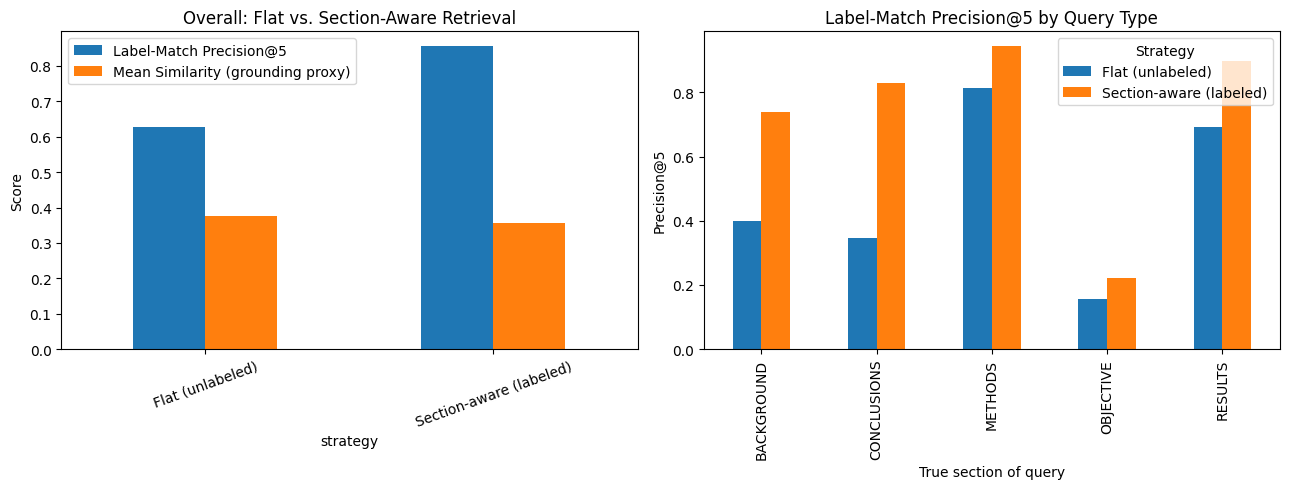

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overall comparison
summary.plot(kind="bar", ax=axes[0])
axes[0].set_title("Overall: Flat vs. Section-Aware Retrieval")
axes[0].set_ylabel("Score")
axes[0].set_xticklabels(summary.index, rotation=20)
axes[0].legend(["Label-Match Precision@5", "Mean Similarity (grounding proxy)"])

# Per-section breakdown of relevance
by_label.plot(kind="bar", ax=axes[1])
axes[1].set_title("Label-Match Precision@5 by Query Type")
axes[1].set_ylabel("Precision@5")
axes[1].set_xlabel("True section of query")
axes[1].legend(title="Strategy")

plt.tight_layout()
plt.show()


## Section 7 — Interpretation and Conclusion

**How to read your results:**
- If `Section-aware (labeled)` shows a materially higher `label_match_precision`
  than `Flat (unlabeled)` in the summary table, that supports the hypothesis
  that section-labeling improves retrieval **relevance**.
- If it also shows a higher `mean_similarity`, that supports the hypothesis
  that section-labeling improves **grounding quality** of the evidence
  handed to a downstream answer generator.
- Check the per-section breakdown: the benefit is expected to be strongest
  for RESULTS and METHODS queries (where vocabulary overlaps most with
  other sections) and weakest for BACKGROUND (which is often more generic
  prose, less confusable with other sections).

**Limitations (for a fair, honest writeup):**
1. **Section classifier ceiling.** The section-aware retriever's quality is
   capped by the classifier's own accuracy (see Section 3's dev score) —
   any misclassified query gets searched in the wrong section entirely.
2. **Proxy grounding metric.** `mean_similarity` is a computationally cheap
   stand-in for true factual grounding. A more rigorous follow-up would
   generate actual answers with an LLM using the retrieved evidence as
   context, then check the generated claims against that evidence with an
   entailment/NLI model — flagged here as direct future work.
3. **TF-IDF ceiling.** TF-IDF captures lexical overlap, not deep semantic
   meaning — it may miss cases where a query and its true evidence use very
   different wording for the same concept. This affects both retrievers
   equally, so it does not bias the *comparison*, but it does put a ceiling
   on absolute performance for both.
4. **Dataset scope.** Findings are specific to RCT abstracts; generalizing
   to other clinical text types (e.g. clinical notes, case reports) would
   require re-validation.

**Suggested extensions:**
- Swap `TfidfVectorizer` for a sentence-transformer embedding model (the
  `BaseRetriever` interface makes this a drop-in change) if GPU access
  becomes available, to test whether the same conclusion holds with
  stronger semantic representations.
- Replace the extractive evaluation with a real LLM generation step for a
  genuine faithfulness/hallucination measurement.
